# Import Modules and Functions

In [1]:
import sys, os

#mod_dir = os.path.abspath('/Users/rangulo/projects/EtaCar_LEs/python')
#sys.path.append(mod_dir)

from LC_utility import *

In [2]:
%load_ext autoreload
%autoreload 2

# Read in Data

In [3]:
## reference tables
table_a57 = pd.read_csv('LC_tables/data/LCref_a57_i.csv')
table_a54 = pd.read_csv('LC_tables/data/LCref_a54_i.csv')

## segment 1
lc_df1 = readin_LCdf('LC_tables/data/LCtable1_i.csv')

## segment 2
lc_df2 = readin_LCdf('LC_tables/data/LCtable2_i.csv')

## segment 3
lc_df3 = readin_LCdf('LC_tables/data/LCtable3_i.csv')

## segment 4
lc_df4 = readin_LCdf('LC_tables/data/LCtable4_i.csv')

In [4]:
### Some images need to be excluded due to quality
### Images from ccd 54 have bad bands (mainly filter i is affected)

# badims_a54i = pd.read_csv('txt_files/ec0915a54i_badims.txt', header=None)[0]
# bad_expnums_a54i = [int(re.search('\.(\d+)_ooi_',os.path.basename(im)).groups()[0]) for im in badims_a54i]


bad_expnums_a54i = pd.read_csv('txt_files/a54i_badims.csv')['a54'].values
bad_expnums_a57i = pd.read_csv('txt_files/a57i_badims.csv')['a57'].values

# bad_expnums_a54i = None
# bad_expnums_a57i = None

# Combine LCs

### Fitting Process for Each Segment

In [5]:
# ### Define uncertainty/error cut on flux error -- exclude outliers from fitting

f_lim = 20.0              # upper limit of flux (muJyas2)
ferr_lim = 1.0            # upper limit of flux error (muJyas2_err)

# ### The working indices for fitting process -- run before the rest
bin_sz = None
flag_inds(lc_df1, f_lm=f_lim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a57i, bin_size=bin_sz)
flag_inds(lc_df2, f_lm=f_lim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a54i, bin_size=bin_sz)
flag_inds(lc_df3, f_lm=f_lim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a54i, bin_size=bin_sz)
flag_inds(lc_df4, f_lm=f_lim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a54i, bin_size=bin_sz)

'Updated LC dataframe -- flagged working indices'

In [20]:
lc_df1.t.columns

Index(['ID', 'x', 'y', 'bsize', 'mjd', 'zpt', 'fluxADU', 'flux_err', 'X2norm',
       'Npix', 'Nmask', 'Jyas2', 'Jyas2_err', 'SB', 'SB_err', 'fitsfile',
       'skip', 'imID', 'filter', 'CONVOL00', 'PHOTNORM', 'KSUM00', 'FSIG00',
       'FSCAT00', 'FWHM', 'M5SIGMA', 'SKYADU', 'muJyas2', 'muJyas2_err',
       'g_ixs_flag'],
      dtype='object')

In [23]:
np.unique(lc_df1.t.ID)

array([0, 1, 2, 3, 4, 5])

In [78]:
np.unique(lc_df2.t['ID'])

array([30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46,
       47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63,
       64, 65, 66, 67])

In [82]:
np.unique(lc_df3.t['ID'])

array([90, 91, 92, 93])

In [83]:
np.unique(lc_df4.t['ID'])

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28])

In [ ]:
filepath = 'https://stsci-transients.stsci.edu/eta/etalc/results/rod_test/goodpos_i/ec0915/57/ec0915a57_goodpos_i_tmpl523435_ID0_lc.txt'


pd.read_csv(filepath, sep='\s+')



0


'Done plotting'

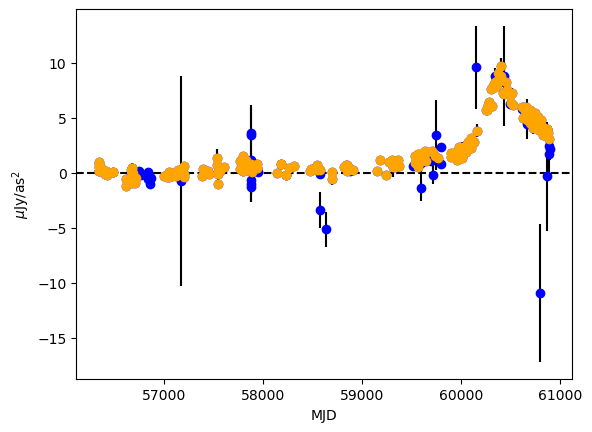

In [88]:
plot_lcs(lc_df1, lc_ID=0, plot_orig=True)

<ErrorbarContainer object of 3 artists>

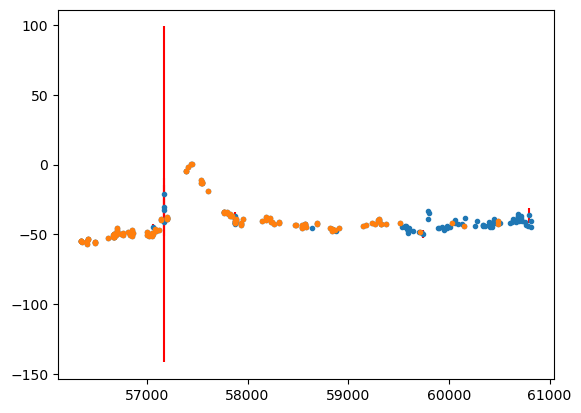

In [98]:

#df = lc_df1.t[lc_df1.t['ID']==2]

df = lc_df2.t[lc_df2.t['ID']==34]


x = df.mjd

y = df.muJyas2

yerr = df.muJyas2_err

plt.errorbar(x, y, yerr, fmt='.', ecolor='r')

#-----
idx = df.g_ixs_flag

x = df.mjd[idx]

y = df.muJyas2[idx]

yerr = df.muJyas2_err[idx]

plt.errorbar(x, y, yerr, fmt='.', ecolor='r')




In [67]:
### Fit LCs to a template
### 1st iteration --> template is an individual LC

## segment 1
templ_ID1 = 2
fit_parms1 = fit_LCs(lc_df1, templ_ID=templ_ID1, metric=1e4)

## segment 2
templ_ID2 = 34
fit_parms2 = fit_LCs(lc_df2, templ_ID=templ_ID2, metric=1e4)

## segment 3
    # specify range where there is a local maximimum (peak)
templ_ID3 = 90
fit_parms3 = fit_LCs(lc_df3, templ_ID=templ_ID3, t_range=[57000,57900], metric=1e4)

## segment 4
    # no tshift as the tail end seems aligned -- also no specific feature to pinpoint
templ_ID4 = 0
fit_parms4 = fit_LCs(lc_df4, templ_ID=templ_ID4, tshift_d=0., metric=None)

In [68]:
fit_parms1

(array([0, 1, 2, 3, 4, 5]),
 [18.158685793161567,
  6.355540027609095,
  0.0,
  -87.16169180715951,
  -66.2792031450299,
  -106.22831188997225],
 [1.4389946512429317,
  1.3019223151478676,
  0.989775514087611,
  1.0420173162250996,
  1.2959016103808492,
  0.7996589021215316],
 [0.011501359320010302,
  0.17155802309090618,
  -0.008356443316063198,
  -0.06470246834192946,
  0.2197527120325334,
  0.5230927537136631])

In [7]:
### Save tshifts for other filters

iparms1 = pd.DataFrame(fit_parms1)
iparms2 = pd.DataFrame(fit_parms2)
iparms3 = pd.DataFrame(fit_parms3)
iparms4 = pd.DataFrame(fit_parms4)

#iparms1.to_csv('LC_tables/fit_params/fparams_i1.csv', index=False)
#iparms2.to_csv('LC_tables/fit_params/fparams_i2.csv', index=False)
#iparms3.to_csv('LC_tables/fit_params/fparams_i3.csv', index=False)
#iparms4.to_csv('LC_tables/fit_params/fparams_i4.csv', index=False)

In [106]:
### Create data frame of aligned and combined LCs

## segment 1
comb1 = get_combLCs(lc_df1, fit_parms1)

## segment 2
comb2 = get_combLCs(lc_df2, fit_parms2)

## segment 3
comb3 = get_combLCs(lc_df3, fit_parms3)

## segment 4
comb4 = get_combLCs(lc_df4, fit_parms4)

In [107]:
### Get LC curve fit using gaussian process

## segment 1
c_t1, c_mu1, c_std1 = get_LCfit(comb1, metric=5e4)

## segment 2
c_t2, c_mu2, c_std2 = get_LCfit(comb2, metric=5e4)

## segment 3
c_t3, c_mu3, c_std3 = get_LCfit(comb3, metric=5e4)

## segment 4
c_t4, c_mu4, c_std4 = get_LCfit(comb4, metric=5e4)

### For Technical paper

In [10]:
image = '../../data/display/ec0915.210122.958767_ooi_i_v1_N22_160305.523435_ooi_i_v1_N22.diff.fits'

with fits.open(image) as im_hdu_diff:
    diff_hdr = im_hdu_diff[0].header
    diff_img = im_hdu_diff[0].data

im_wcs = WCS(diff_hdr)

In [11]:
from regions import Regions

In [12]:
reg_locs = Regions.read('../../region_files/ec0915/ec0915a54_goodpos.reg', format='ds9')[29:67]
pix_locs = []
for i in reg_locs:
    pix_locs.append(im_wcs.world_to_pixel(i.center))

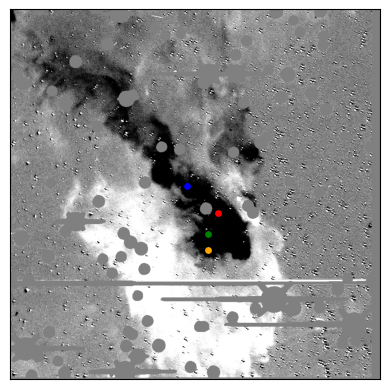

In [13]:
color_r = ['blue', 'red', 'green', 'orange']

ax=plt.gca()
ax.imshow(diff_img, vmin=-100, vmax=100, cmap='gray', origin='lower')
sel_inds = [36, 33, 15, 0]
for i, ii in enumerate(sel_inds):
    p = pix_locs[ii]
    plt.scatter(p[0],p[1], s=15, color=color_r[i])

ax.set_xlim(3450,4500)
ax.set_ylim(450,1500)

ax.set_xticks([])
ax.set_yticks([])

plt.savefig('LE_extract_locs.png', bbox_inches = 'tight', dpi=100)

plt.show()

66
67
69
74


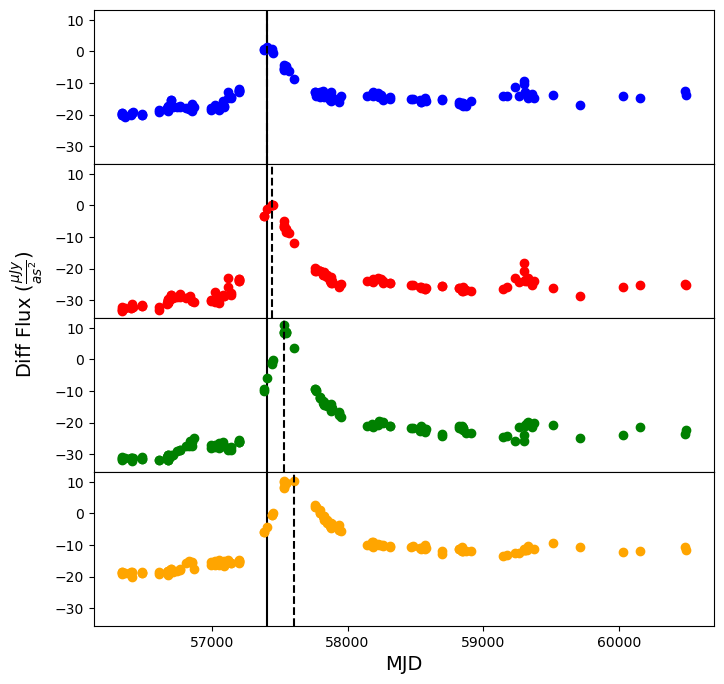

In [14]:
group_inds = np.where(table_a54['group']==1)[0]
table_ids = table_a54.loc[np.array(group_inds)[sel_inds],'ID'].values

fig, axs = plt.subplots(4,1,dpi = 100, figsize = [8,8], sharex=True, sharey=True)
axs = axs.flatten()

for i, idd in enumerate(table_ids): 
    check_inds = np.where(lc_df2.t['ID'].eq(idd) & lc_df2.t['g_ixs_flag'].eq(True))[0]
    # ch_t, ch_mu, ch_std = get_LCfit(lc_df2,indices=check_inds, metric=1e4)

    axs[i].scatter(lc_df2.t.loc[check_inds,'mjd'], lc_df2.t.loc[check_inds,'muJyas2'], color=color_r[i])
    print(np.where(lc_df2.t.loc[check_inds,'muJyas2']==max(lc_df2.t.loc[check_inds,'muJyas2']))[0][0])
    axs[i].axvline(lc_df2.t.loc[check_inds[np.where(lc_df2.t.loc[check_inds,'muJyas2']==max(lc_df2.t.loc[check_inds,'muJyas2']))[0][0]],'mjd'], color='k', ls='--')
    if i==0:
        px0 = lc_df2.t.loc[check_inds[np.where(lc_df2.t.loc[check_inds,'muJyas2']==max(lc_df2.t.loc[check_inds,'muJyas2']))[0][0]],'mjd']
    axs[i].axvline(px0, color='k', zorder=0)
    # plt.scatter(ch_t,ch_mu)

    # tpeak = find_t_peak(ch_t,ch_mu,ch_std, metric=None, t_range=[57000,57900])
    # plt.axvline(tpeak)

fig.subplots_adjust(wspace=0, hspace=0)
axs[-1].set_xlabel('MJD', fontsize=14)
fig.supylabel('Diff Flux ($\\frac{{\\mu}Jy}{{as}^2}$)', fontsize=14)

plt.savefig('LE_extracted.png', bbox_inches = 'tight', dpi=100)

plt.show()

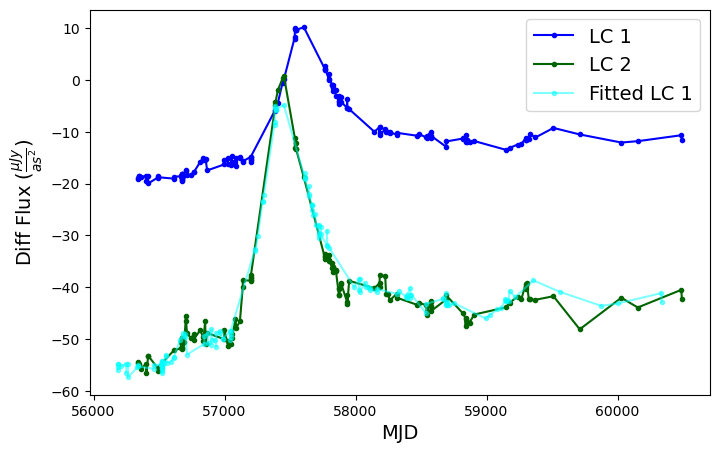

In [15]:
## template
g1_inds = np.where(lc_df2.t['ID'].eq(templ_ID2) & lc_df2.t['g_ixs_flag'].eq(True))[0]
t1 = lc_df2.t.loc[g1_inds,'mjd'].values
f1 = lc_df2.t.loc[g1_inds,'muJyas2'].values
f1_err = lc_df2.t.loc[g1_inds,'muJyas2_err'].values

## lc
lc_id = table_ids[-1]
g2_inds = np.where(lc_df2.t['ID'].eq(lc_id) & lc_df2.t['g_ixs_flag'].eq(True))[0]
t2 = lc_df2.t.loc[g2_inds,'mjd'].values
f2 = lc_df2.t.loc[g2_inds,'muJyas2'].values
f2_err = lc_df2.t.loc[g2_inds,'muJyas2_err'].values

lc_ids, tshifts, a_norms, b_offsets = fit_parms2
parm_ind = np.where(lc_ids==lc_id)[0][0]

tshift = tshifts[parm_ind]
a = a_norms[parm_ind]
b = b_offsets[parm_ind]

plt.figure(figsize=(8,5))

plt.errorbar(t2, f2, label='LC 1', fmt='.-', color='blue')
plt.errorbar(t1, f1, label='LC 2', color='darkgreen', fmt='.-')
plt.errorbar(t2-tshift, f2*a + b, alpha=.5, label='Fitted LC 1', fmt='.-', color='cyan')

plt.ylabel('Diff Flux ($\\frac{{\\mu}Jy}{{as}^2}$)', fontsize=14)
plt.xlabel('MJD', fontsize=14)

plt.legend(fontsize=14)

plt.savefig('LE_aligning.png', bbox_inches = 'tight', dpi=100)

### See/Check Fitting Process

0


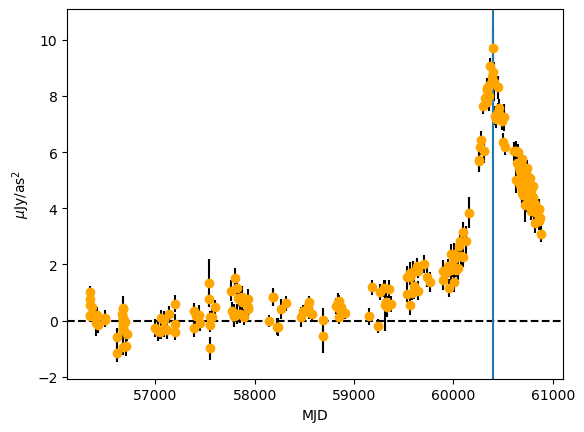

1


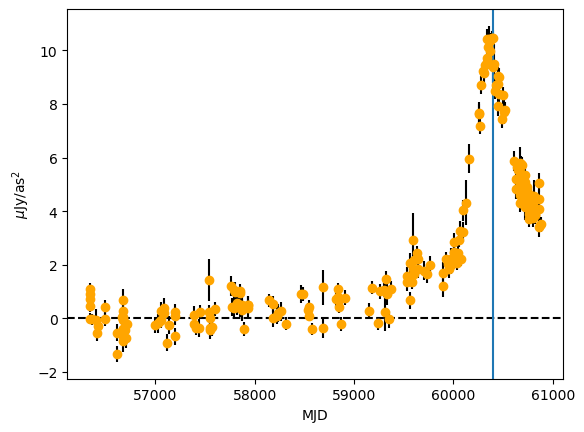

2


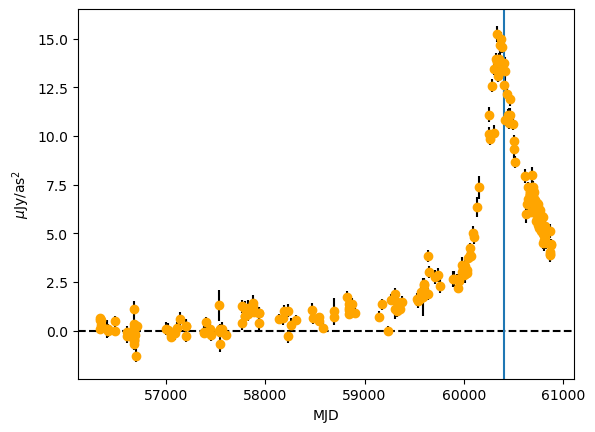

3


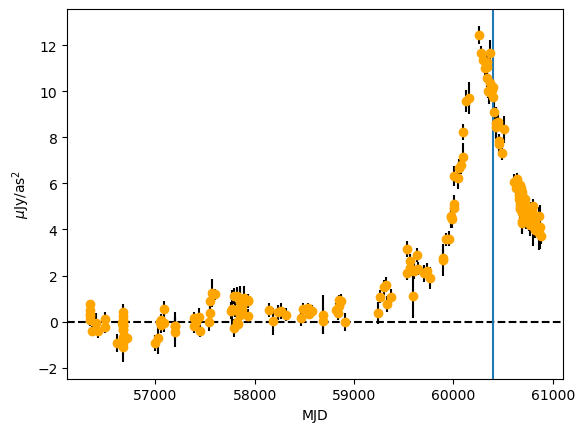

4


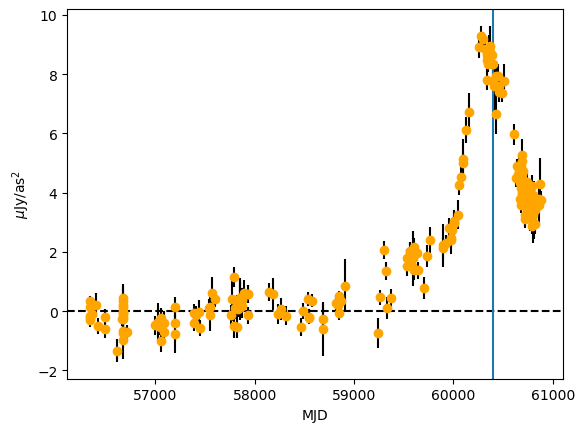

5


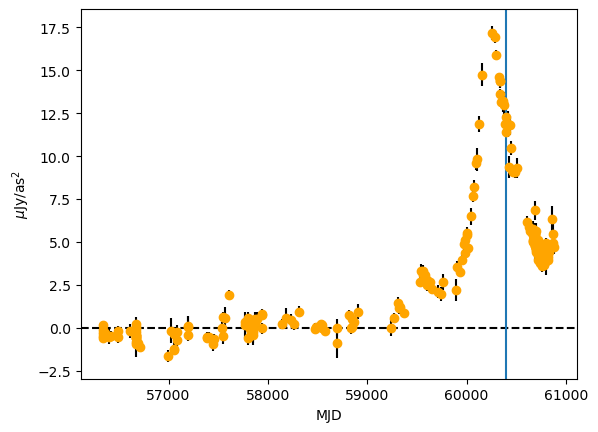

'Done plotting'

In [100]:
### See individual LCs

## 4 segments (labelled 1-4)

#plot_lcs(lc_df2, plot_orig=True)
plot_lcs(lc_df1, plt_xl=60400)

In [17]:
### Check how peaks are found

# ch_df = lc_df2
# lc_ids = np.unique(ch_df.t['ID'])
# for i in lc_ids: 
#     check_inds = np.where(ch_df.t['ID'].eq(i) & ch_df.t['g_ixs_flag'].eq(True))[0]
#     ch_t, ch_mu, ch_std = get_LCfit(ch_df,indices=check_inds, metric=1e4)

#     plt.scatter(ch_df.t.loc[check_inds,'mjd'], ch_df.t.loc[check_inds,'muJyas2'])
#     plt.scatter(ch_t,ch_mu)

#     # tpeak = find_t_peak(ch_t,ch_mu,ch_std, metric=None, t_range=[57000,57900])
#     # plt.axvline(tpeak)
    
#     plt.show()

'Plotting LC fits'

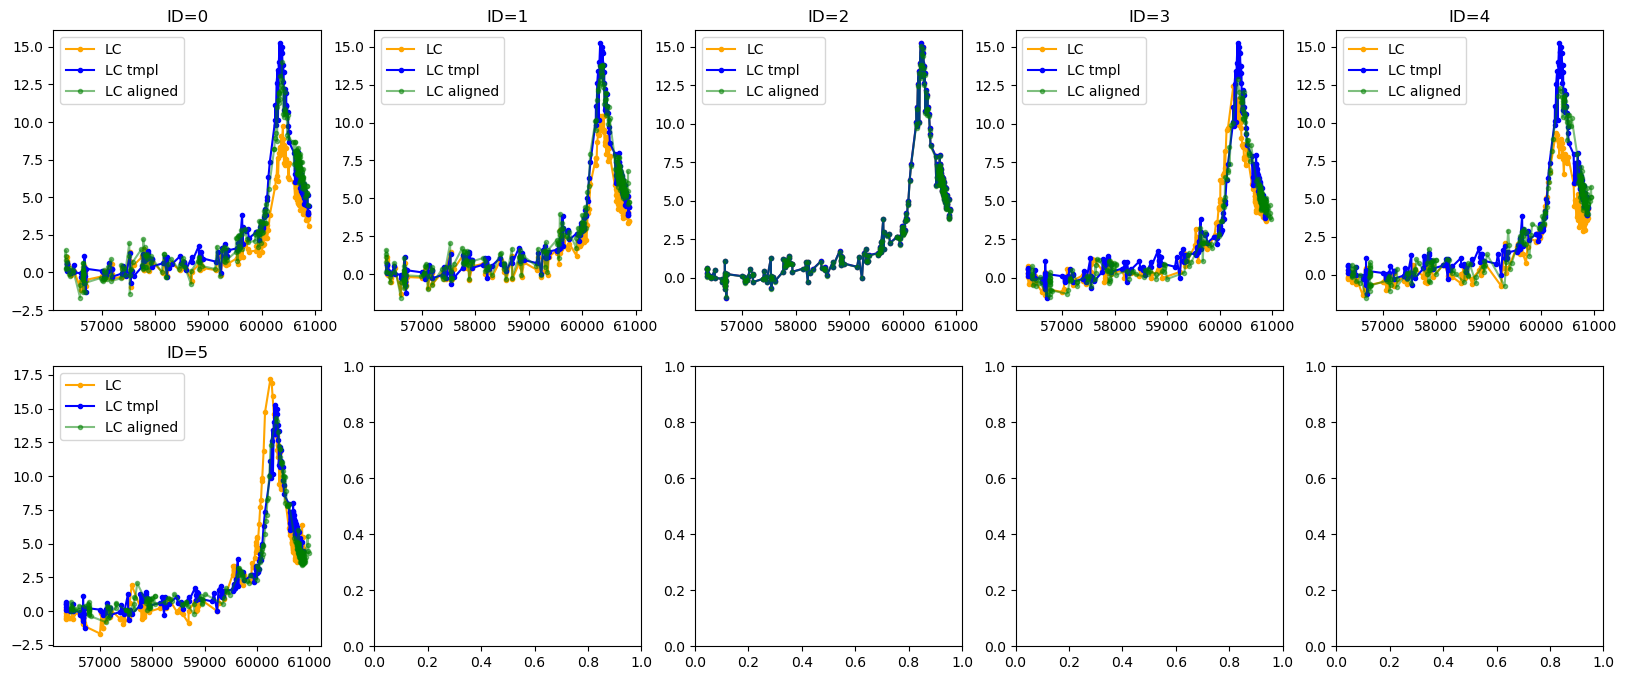

In [102]:
### See Fitting Process

df = lc_df1
fit_ps = fit_parms1
t_ID = templ_ID1
plot_LCfits(df,fit_ps, templ_ID=t_ID)

In [134]:
pd.DataFrame(fit_parms1)

,0,1,2,3,4,5
0,0.000000,1.000000,2.000000,3.000000,4.000000,5.000000
1,18.158686,6.355540,0.000000,-87.161692,-66.279203,-106.228312
2,1.438995,1.301922,0.989776,1.042017,1.295902,0.799659
3,0.011501,0.171558,-0.008356,-0.064702,0.219753,0.523093


In [139]:
fit_parms1[0]

array([0, 1, 2, 3, 4, 5])

In [140]:
fit_parms1[1]

[18.158685793161567,
 6.355540027609095,
 0.0,
 -87.16169180715951,
 -66.2792031450299,
 -106.22831188997225]

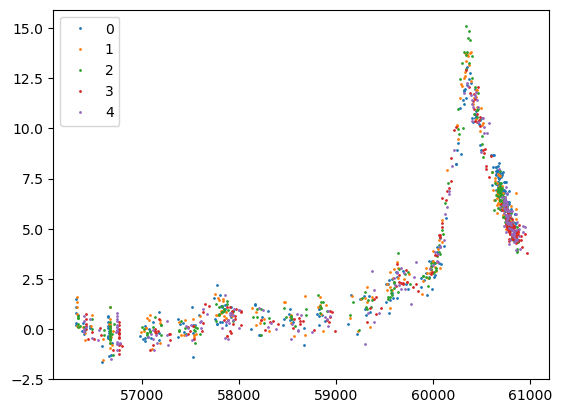

In [334]:

#df = lc_df1.t[lc_df1.t['ID']==2]

lc_ids, tshifts, a_norms, b_offsets = fit_parms1


t_all = []
f_all = []
ferr_all = []
for i in range(5):

    df = lc_df1.t[lc_df1.t['ID']==i]
    
    #-----
    idx = df.g_ixs_flag
    
    x = df.mjd[idx]
    
    y = df.muJyas2[idx]
    
    yerr = df.muJyas2_err[idx]


    x = x[yerr<0.7]
    y = y[yerr<0.7]
    yerr = yerr[yerr<0.7]
    

    tshift = tshifts[i]
    a_norm = a_norms[i]
    b_offset = b_offsets[i]
    
    plt.errorbar(x-tshift, y*a_norm + b_offset, fmt='.', ecolor='r',markersize=2, label=i)
    #plt.plot(x-tshift, y*a_norm + b_offset, '.', label=i)

    t_all.append(x-tshift)
    f_all.append(y*a_norm + b_offset)
    ferr_all.append(a_norm*yerr)

t_all = np.concatenate(t_all)
f_all = np.concatenate(f_all)
ferr_all = np.concatenate(ferr_all)

plt.legend()

#plt.xlim([56000, 59000])
#plt.ylim([-2.5, 3])

<ErrorbarContainer object of 3 artists>

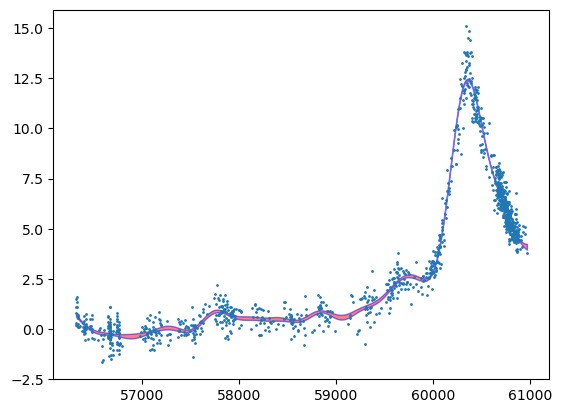

In [326]:


#-----

x = t_all[t_all>56200]

y = f_all[t_all>56200]

yerr = ferr_all[t_all>56200]

#x = comb_df.t.loc[inds,'mjd']
#y = comb_df.t.loc[inds,'muJyas2']
#yerr = comb_df.t.loc[inds,'muJyas2_err']

kernel = ExpSquaredKernel(metric=5e4)
gp = george.GP(kernel)
gp.compute(x, yerr)

t = np.linspace(min(x), max(x), 5000)
mu, cov = gp.predict(y, t)
std = np.sqrt(np.diag(cov))

plt.fill_between(t, mu-std, mu+std, alpha=0.5, color='r', edgecolor='blue', )

plt.errorbar(x, y, fmt='.', markersize=2, ecolor='b', )

#plt.ylim([-2, 3])
#plt.xlim([56000, 59000])


{'x': array([56323.05242421, 56323.05738021, 56323.06031421, ...,
        60930.27202015, 60931.27191415, 60946.25382715]),
 'y': array([0.28535264, 0.28693553, 0.28506484, ..., 0.86281129, 0.51330663,
        0.40328458])}

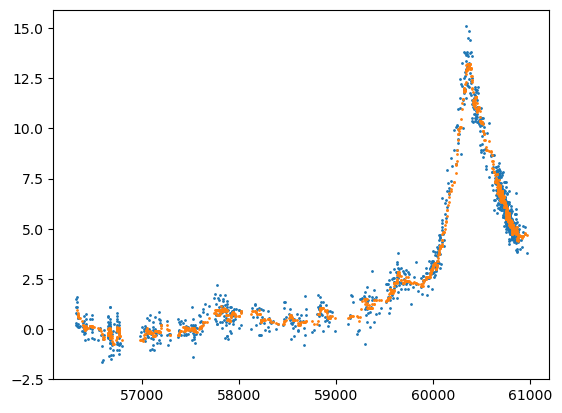

In [331]:
df = pd.DataFrame({'x':x, 'y':y, 'yerr':yerr})
df = df.sort_values(by='x')

df['y_smooth'] = df['y'].rolling(window=10).median()

plt.plot(df.x, df.y, '.', markersize=2)

plt.plot(df.x, df.y_smooth, '.', markersize=2)


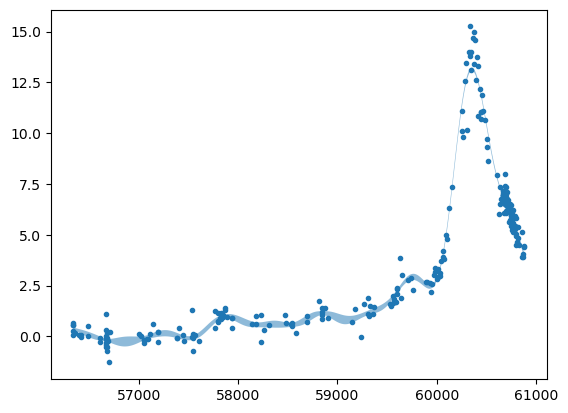

In [225]:

df = lc_df1.t[lc_df1.t['ID']==2]

#-----
idx = df.g_ixs_flag

x = df.mjd[idx] 

y = df.muJyas2[idx] 

yerr = df.muJyas2_err[idx]  


#x = comb_df.t.loc[inds,'mjd']
#y = comb_df.t.loc[inds,'muJyas2']
#yerr = comb_df.t.loc[inds,'muJyas2_err']

kernel = ExpSquaredKernel(metric=5e4)
gp = george.GP(kernel)
gp.compute(x, yerr)


t = np.linspace(min(x), max(x), 5000)
mu, cov = gp.predict(y, t)
std = np.sqrt(np.diag(cov))

plt.plot(x, y, '.')
plt.fill_between(t, mu-std, mu+std, alpha=0.5)

In [237]:
df.columns

Index(['ID', 'x', 'y', 'bsize', 'mjd', 'zpt', 'fluxADU', 'flux_err', 'X2norm',
       'Npix', 'Nmask', 'Jyas2', 'Jyas2_err', 'SB', 'SB_err', 'fitsfile',
       'skip', 'imID', 'filter', 'CONVOL00', 'PHOTNORM', 'KSUM00', 'FSIG00',
       'FSCAT00', 'FWHM', 'M5SIGMA', 'SKYADU', 'muJyas2', 'muJyas2_err',
       'g_ixs_flag', 'new_mjd', 'new_muJyas2', 'new_muJyas2_err'],
      dtype='object')

In [245]:
df[df.g_ixs_flag][:50][ ['ID', 'x', 'y', 'mjd', 'muJyas2', 'muJyas2_err', 'g_ixs_flag',
                        'CONVOL00', 'PHOTNORM', 'KSUM00', 'FSIG00',
                        'FSCAT00', 'FWHM', 'M5SIGMA', 'SKYADU',]]

,ID,x,y,mjd,muJyas2,muJyas2_err,g_ixs_flag,CONVOL00,PHOTNORM,KSUM00,FSIG00,FSCAT00,FWHM,M5SIGMA,SKYADU
972,3,2046,2331,56341.211110,0.32790,0.1880,True,TEMPLATE,t,1.0856,1.384,0.109,3.834,23.216,1025.0
973,3,2046,2331,56341.216066,0.77240,0.1838,True,TEMPLATE,t,1.0883,1.335,0.080,4.222,23.151,1006.0
974,3,2046,2331,56341.219000,0.22720,0.1805,True,TEMPLATE,t,1.1000,1.419,0.123,3.981,23.186,1023.0
975,3,2046,2331,56343.220957,0.52180,0.2492,True,TEMPLATE,t,1.1045,1.460,0.141,4.085,23.083,1220.0
976,3,2046,2331,56343.222439,0.05590,0.2407,True,TEMPLATE,t,1.1069,1.426,0.125,4.061,23.063,1233.0
977,3,2046,2331,56360.212694,-0.40650,0.2235,True,TEMPLATE,t,1.0700,1.526,0.191,3.383,23.338,1039.0
978,3,2046,2331,56402.978833,-0.07813,0.4561,True,TEMPLATE,t,0.8680,1.174,0.066,3.946,22.264,3670.0
982,3,2046,2331,56418.975542,-0.42050,0.2800,True,TEMPLATE,t,1.0904,1.085,0.058,4.449,22.706,2011.0
983,3,2046,2331,56487.986817,0.10200,0.3023,True,TEMPLATE,t,1.0799,1.270,0.063,4.223,22.782,1718.0
984,3,2046,2331,56488.986801,-0.24450,0.2511,True,TEMPLATE,t,1.0940,1.322,0.094,3.546,22.933,1823.0


In [104]:
### See comb LCs

# df = lc_df1
# fit_ps = fit_parms1
# t_ID = templ_ID1

# for i in fit_ps[0]:
#     df_inds = get_LCinds(df, lc_ID=i)
#     plt.errorbar(df.t.loc[df_inds,'new_mjd'], df.t.loc[df_inds,'new_muJyas2'], yerr=df.t.loc[df_inds,'new_muJyas2_err'], fmt='.-', ecolor='black')

In [20]:
### See combined LC

# c_df = comb4
# t_mns = c_t4
# f_mns = c_mu4
# f_mers = c_std4

# plt.errorbar(c_df.t['mjd'], c_df.t['muJyas2'], fmt='.', color='blue', alpha=0.25)
# plt.axhline(y=0, linestyle='--', color='black')
# plt.errorbar(t_mns, f_mns, fmt='--.', ecolor='black', color='orange') #,yerr=f_mers

# plt.xlabel('MJD')
# plt.ylabel('$\mu$Jy/as$^2$')
# plt.show()

# Model LC

### Combine Segments

In [113]:
### Fit segments with overlap

tshiftm21, am21, bm21 = get_tshift_scale_offset(c_t2, c_mu2, c_std2, c_t1, c_mu1, c_std1)

# define peaks to use in fitting (see LC)
t_pm2 = find_t_peak(c_t2,c_mu2,c_std2, metric=None, t_range=[59000,60000])
t_pm3 = find_t_peak(c_t3,c_mu3,c_std3, metric=None, t_range=[57000,57800])
tshiftm23, am23, bm23 = get_tshift_scale_offset(c_t2, c_mu2, c_std2, c_t3, c_mu3, c_std3, t_peaks=[t_pm2,t_pm3])


# fit segment 4 to segment 3 after its been fitted to segment 2
m_t3 = c_t3-tshiftm23
m_f3 = am23*c_mu3+bm23
m_ferr3 = am23*c_std3

tshiftm34, am34, bm34 = get_tshift_scale_offset(m_t3, m_f3, m_ferr3, c_t4, c_mu4, c_std4, tshift_d=-4450)


# ## From running with bad images (improves overlap)
# tshiftm21 = 2921.78
# am21 = 4.26
# bm21 = -59.89

# tshiftm23 = -1783.25
# am23 = 2.16
# bm23 = -40.08

# tshiftm34 = -4450
# am34 = 2.66
# bm34 = -44.22

In [ ]:
plt.plot();

In [114]:
print(tshiftm21, tshiftm23, tshiftm34)
print(tshiftm34, am34, bm34)

2921.0512113254954 -1771.914574022776 -4450
-4450 2.736416901851292 -44.61646378500505


In [23]:
# am34 = 3.0
# bm34 = -44.

In [115]:
### Combine Segments
    ## Combine model data

# offsetm = 65.2       # look at plot to decide
offsetm = 65.

m_t1 = c_t1-tshiftm21
m_f1 = (am21*c_mu1+bm21)+offsetm
m_ferr1 = am21*c_std1

m_t2 = c_t2
m_f2 = c_mu2+offsetm
m_ferr2 = c_std2

m_t3 = c_t3-tshiftm23
m_f3 = (am23*c_mu3+bm23)+offsetm
m_ferr3 = am23*c_std3

m_t4 = c_t4-tshiftm34
m_f4 = (am34*c_mu4+bm34)+offsetm
m_ferr4 = am34*c_std4

In [117]:
### Combine Segments
    ## Combine LC data

fin_t1 = comb1.t['mjd'].values-tshiftm21
fin_f1 = (am21*comb1.t['muJyas2'].values+bm21)+offsetm
fin_ferr1 = am21*comb1.t['muJyas2_err'].values

fin_t2 = comb2.t['mjd'].values
fin_f2 = comb2.t['muJyas2'].values+offsetm
fin_ferr2 = comb2.t['muJyas2_err'].values

fin_t3 = comb3.t['mjd'].values-tshiftm23
fin_f3 = (am23*comb3.t['muJyas2'].values+bm23)+offsetm
fin_ferr3 = am23*comb3.t['muJyas2_err'].values

fin_t4 = comb4.t['mjd'].values-tshiftm34
fin_f4 = (am34*comb4.t['muJyas2'].values+bm34)+offsetm
fin_ferr4 = am34*comb4.t['muJyas2_err'].values


tls_m = np.concatenate([fin_t1, fin_t2, fin_t3, fin_t4])
fls_m = np.concatenate([fin_f1, fin_f2, fin_f3, fin_f4])
ferrls_m = np.concatenate([fin_ferr1, fin_ferr2, fin_ferr3, fin_ferr4])

ord_inds_m = tls_m.argsort()
tls_m = tls_m[ord_inds_m]
fls_m = fls_m[ord_inds_m]
ferrls_m = ferrls_m[ord_inds_m]

comb_m_data = {'mjd': tls_m, 'muJyas2': fls_m, 'muJyas2_err': ferrls_m}
comb_m = pdastrostatsclass()
comb_m.t = comb_m.t.assign(**comb_m_data)

## Save table for bookkeeping purposes
comb_m.t.to_csv('LC_tables/models/iLC_data1.csv', index=False)

In [118]:
### Save tshifts for fitting in other filters

tshifts_i = {'tshift': [tshiftm21, 0., tshiftm23, tshiftm34]}
tshifts_tab = pd.DataFrame(tshifts_i)
tshifts_tab.to_csv('LC_tables/fit_params/mtshifts_i1.csv', index=False)

In [119]:
### Create the model (LC_0)

m_t, m_mu, m_std = get_LCfit(comb_m, metric=3e4)

lc_model = {'mjd':m_t, 'muJyas2':m_mu, 'muJyas2_err':m_std}
lc_model_d = pd.DataFrame(lc_model)

lc_model_d.to_csv('LC_tables/models/iLC_m1.csv', index=False)

### See Model Fitting

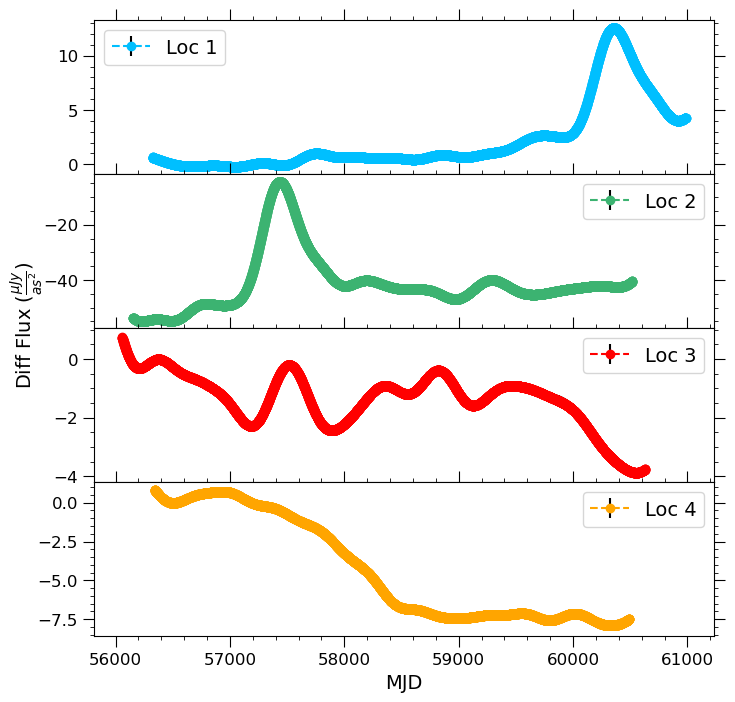

In [120]:
### Individual Segements

fig, axs = plt.subplots(4,1, dpi = 100, figsize = [8,8], sharex=True)

axs = axs.flatten()
axs[3].set_xlabel('MJD', fontsize=14)

axs[0].errorbar(c_t1, c_mu1, yerr=c_std1, fmt='--o', ecolor='black', color='deepskyblue', label='Loc 1')
axs[1].errorbar(c_t2, c_mu2, yerr=c_std2, fmt='--o', ecolor='black', color='mediumseagreen', label='Loc 2')
axs[2].errorbar(c_t3, c_mu3, yerr=c_std3, fmt='--o', ecolor='black', color='red', label='Loc 3')
axs[3].errorbar(c_t4, c_mu4, yerr=c_std4, fmt='--o', ecolor='black', color='orange', label='Loc 4')

for ax in axs:
    ax.minorticks_on()
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=8)
    ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=3)
    # ax.set_ylabel('$\mu$Jy/as$^2$', fontsize = 14)
    ax.legend(fontsize = 14)

fig.subplots_adjust(wspace=0, hspace=0)
fig.supylabel('Diff Flux ($\\frac{{\\mu}Jy}{{as}^2}$)', fontsize=14)

# axs[1].axvline(find_t_peak(c_t2,c_mu2,c_std2, metric=None, t_range=[59000,60000]))
# axs[2].axvline(find_t_peak(c_t3,c_mu3,c_std3, metric=None, t_range=[57000,57800]))

fig.savefig('segments.png', bbox_inches = 'tight', dpi=100)

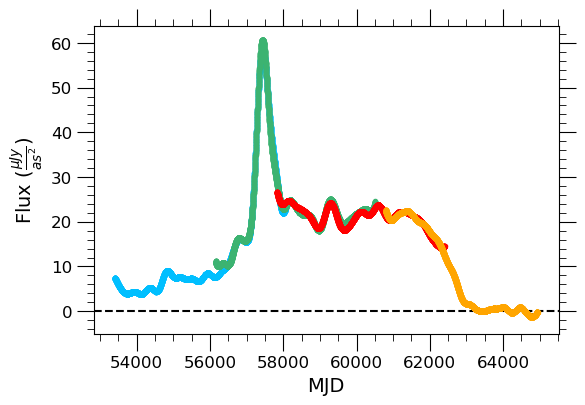

In [121]:
### See Connected Segments

fig, ax = plt.subplots(dpi = 100, figsize = [6,4])
ax.minorticks_on()
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
ax.set_xlabel('MJD', fontsize = 14)
ax.set_ylabel('Flux ($\\frac{{\\mu}Jy}{{as}^2}$)', fontsize = 14)
ax.ticklabel_format(axis='both', style='plain')


ax.errorbar(m_t1, m_f1, yerr=m_ferr1, fmt='--.', ecolor='black', color='deepskyblue', label='Loc 1')
ax.errorbar(m_t2, m_f2, yerr=m_ferr2, fmt='--.', ecolor='black', color='mediumseagreen', label='Loc 2')
ax.errorbar(m_t3, m_f3, yerr=m_ferr3, fmt='--.', ecolor='black', color='red', label='Loc 3')
ax.errorbar(m_t4, m_f4, yerr=m_ferr4, fmt='--.', ecolor='black', color='orange', label='Loc 4')

ax.axhline(y=0, ls='--', color='k')

fig.savefig('combined_segments.png', bbox_inches = 'tight', dpi=100)

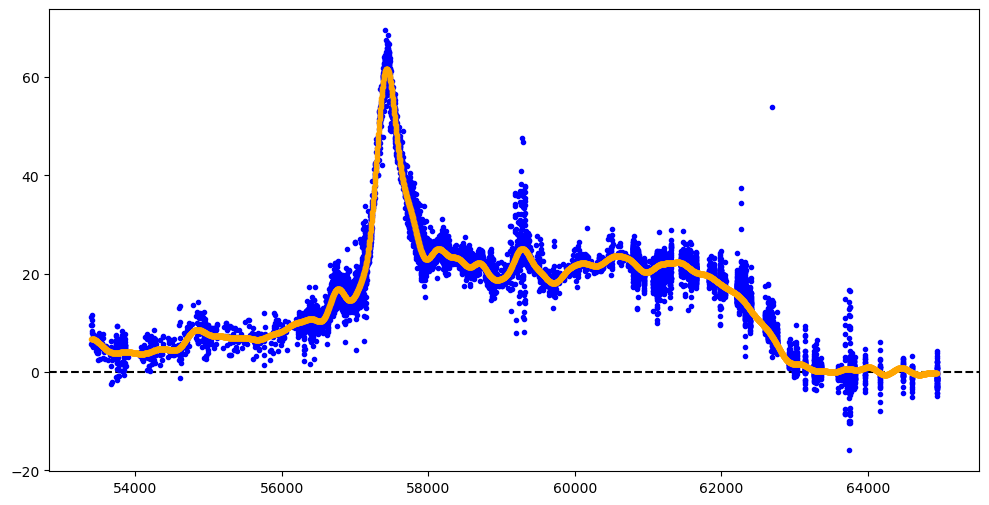

In [122]:
### Plot Model
plt.subplots(dpi = 100, figsize = [12,6])
plt.errorbar(comb_m.t['mjd'], comb_m.t['muJyas2'], fmt='.', ecolor='black', color='blue')
plt.errorbar(m_t, m_mu, fmt='--.', ecolor='black', color='orange')
plt.axhline(y=0, linestyle='--', color='black')